# Final Project - Cellular Automata Edge Detector
###Description
Cellular automata are mathematical models that change pixel states according to their neighboring pixels' state. In the case of a binary image, each pixel's next state is determined by looking at its neighbors in a 3x3 window. Similar to Assignment 2 Part B, there is a 9-bit rules table.

###Instructions

Given a randomly generated 256x256 binary image and a set of rules, write a GA that produces an image showing the edges of the given image.

For this assignment there are only two rules:

0 means change the center pixel to 0 (white)

000010000 becomes 000000000

1 means change the center pixel to 1 (black)

000000000 becomes 000010000

If the 3x3 window is

110

001

101

Then the corresponding rule will match 110001101 in the rules table.

When initializing the population, the start image and goal image will be saved in a JSON file with greyscale values of 0 or 255. After reading in the given image from the JSON file, convert it to a binary image so that each pixel corresponds to 0 or 1.

Similar to Assignment 2 Part B, you will need to implement a 3x3 sliding window that wraps around. This means that if you reach the right edge of the image, you will loop back to the left edge of the image. If you reach the bottom edge of the image, you will loop back to the top edge of the image. Once each pixel in the image has been updated, one pass is completed.

###Bonus Points

You can get additional points by trying to evolve a ruleset that will work with any image. Pick any image that you'd like and upload it to the workbook. Before initializing the population, insert the uploaded image name between the quotes into the following code (you will see this below in the workbook)

initial_image = cv2.imread(" ", 0)

Then change bonus to True in the initialize_population function. Now you can initialize your population as normal.

###Note:

Population is a JSON file with the desired number (population_size) of individuals. The first element corresponds to the image in greyscale.

Running the intialize_population function, generates the JSON file - CellularAutomata.json.

Please reach out to the Programmer on Duty, Koa, if you need any clarification on the assignment instructions.

# Supporting Codes
Below are the supporting codes necessary to generate the initial population and generate the JSON file "CellularAutomata.json".

**Whenever you open the notebook just run the below codes once**.

After running them once all the functions can be reused anywhere in the notebook.

##**Make sure you upload the image "binaryhand.png" before running the code below**

In [0]:
## Importing all the packages
import numpy as np
import random
import json
import cv2
from google.colab.patches import cv2_imshow

In [0]:
################################################################################
#
#   Writes the initial_image and goal_imate to a JSON file. Initializes the 
#   population of candidates with a size of population_size. Writes this 
#   population to the JSON file.
#
#   The JSON file is called "CellularAutomata.json"
#   
#
#   Parameters:
#   initial_image - the greyscale image "binaryhand.png"
#   population_size - an integer defining how many rules tables to generate
#
################################################################################
def initialize_population(initial_image, population_size=3, bonus=False):
    new_population = []
    random_truth_table = []
    if bonus == False:
      a = np.array([[random.uniform(0.25, 1.5), 0.0],
                [0.0, random.uniform(0.25, 1.5)]])
    
      M, N = initial_image.shape
      points = np.mgrid[0:N, 0:M].reshape((2, M*N))
      new_points = np.linalg.inv(a).dot(points).round().astype(int)
      x, y = new_points.reshape((2, M, N), order='F')
      indices = x + N*y

      transformed_image = np.take(initial_image, indices, mode='wrap')
      goal_image = cv2.Canny(transformed_image, 256, 256)

      new_population.append(transformed_image.tolist())
      new_population.append(goal_image.tolist())

    elif bonus == True:
      for x_pixel in range(len(initial_image)):
        for y_pixel in range(len(initial_image[0])):
          if initial_image[x_pixel][y_pixel] < 128:
            initial_image[x_pixel][y_pixel] = 0
          elif initial_image[x_pixel][y_pixel] >= 128:
            initial_image[x_pixel][y_pixel] = 255
      
      goal_image = cv2.Canny(initial_image, len(initial_image), len(initial_image[0]))

      new_population.append(initial_image.tolist())
      new_population.append(goal_image.tolist())

    for individual in range(population_size):
      random_truth_table= list()
      for bit in range(512):
        key = format(bit, 'b')
        while len(key) != 9:
          key = "0" + key
        random_truth_table.append({key: np.random.randint(2)})
      new_population.append(random_truth_table)
    
    with open("CellularAutomata.json", 'w') as o:
      o.write(json.dumps(new_population))

## Generating Initial Population

After running all the codes above once, use the function **initialize_population(intial_image, population_size, bonus)** to create the JSON file and initialize the population.

One JSON file is generated: CellularAutomata.json.

Download this file and use it as need.

In [0]:
initial_image = cv2.imread("binaryhand.png", 0)

initialize_population(initial_image, population_size = 5, bonus = False)

with open("CellularAutomata.json",'r') as f:
  population = json.loads(f.read());

# Viewing an Image

To visualize your image, use the function visualize_image().

In [0]:
def visualize_image(image):
  cv2_imshow(image)

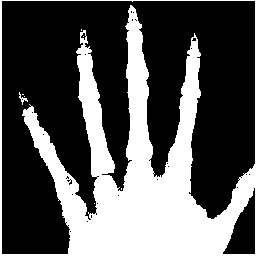

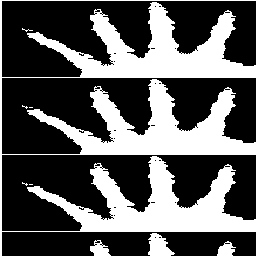

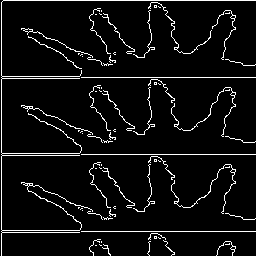

In [123]:
start_image = np.asarray(population[0])
goal_image = np.asarray(population[1])

visualize_image(initial_image)
visualize_image(start_image)
visualize_image(goal_image)

# Visualizing a Population

To visualize your population, use the function print_population().

If you have modified the population while running your GA, make sure it matches the same format as the initial_population. Refer to initialize_population for the format.


In [0]:
################################################################################
#
#   Prints the passed in population population
#
#   Parameters:
#   population_json - json object containing the population to print
#
################################################################################
def print_population(population_json):
  json_obj = json.loads(population_json)

  for individual in range(len(population)):
      print(population[individual])

In [0]:
print_population(json.dumps(population))

[[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255

# Fitness Evaluation

Fitness of an individual is calculated using Hamming Distance. For each pixel that does not match in the two images, fitness goes up by 1. A lower fitness value is better.

A sample of the fitness evaluation(written in python) is shared, please refer to the function calculate_fitness().

In [0]:
################################################################################
#
#   Calculates the Hamming Distance between the final generated image and the
#   a sample edge set calculated using cv2. Each bit is compared one by one. 
#   Every time two bits do not match, 1 is added to the fitness. A lower fitness
#   is better.
#
#   Parameters:
#   initial_image - the image generated by initialize_population
#   final_image - the result of applying the rules on the initial_image
#
#   Returns:
#   an integer corresponding to the number of bit
#
################################################################################
def calculate_fitness(start_image, final_image):
  edges = cv2.Canny(start_image, 256, 256)
  fitness = 0

  for x_pixel in range(len(start_image)):
    for y_pixel in range(len(start_image)):
      if final_image[x_pixel][y_pixel] != edges[x_pixel][y_pixel]:
        fitness = fitness + 1

  return fitness

In [0]:
calculate_fitness(initial_image, start_image)

17476